<a href="https://colab.research.google.com/github/teejiayi99-droid/KQC-7016-Lab-1-2-3/blob/main/lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
# LAB 3: Statistical Methods
# Topic: Two-Way ANOVA - Does GDP Level and Population Level affect Oil Consumption?


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from google.colab import drive
plt.style.use('seaborn-v0_8')

# 1. Mount Google Drive
drive.mount('/content/drive')

# Load dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/WorldEnergy.csv')

# 2. CLEAN COLUMN NAMES

df.columns = df.columns.str.strip().str.replace(" ", "_").str.lower()

gdp_col = "gdp"
oil_col = "oil_consumption"
year_col = "year"
country_col = "country"

print(f"Using columns → GDP: {gdp_col} | Oil: {oil_col} | Year: {year_col}")

# 3. FILTER & CLEAN DATA

# Keep only recent data
df = df[df[year_col] >= 2000].copy()

# Remove rows with missing OR zero values (IMPORTANT)
df = df.dropna(subset=[gdp_col, oil_col, 'population'])

df = df[
    (df[gdp_col] > 0) &
    (df[oil_col] > 0) &
    (df['population'] > 0)
]

# Remove countries with insufficient data (at least 15 years)
valid_countries = df.groupby(country_col).size()
valid_countries = valid_countries[valid_countries >= 15].index
df = df[df[country_col].isin(valid_countries)].copy()

print("After filtering:", df.shape)

# 4.1 Handle missing values
df = df.sort_values([country_col, year_col])
df[gdp_col] = df.groupby(country_col)[gdp_col].ffill().bfill()
df[oil_col] = df.groupby(country_col)[oil_col].ffill().bfill()

df[gdp_col] = df[gdp_col].fillna(df[gdp_col].median())
df[oil_col] = df[oil_col].fillna(df[oil_col].median())

# 4.2 REMOVE OUTLIERS USING IQR

def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return data[(data[column] >= lower) & (data[column] <= upper)]

# Apply to key variables
df = remove_outliers_iqr(df, gdp_col)
df = remove_outliers_iqr(df, oil_col)

print("After outlier removal:", df.shape)

# Reduce skewness
df[gdp_col] = np.log1p(df[gdp_col])
df[oil_col] = np.log1p(df[oil_col])

# 4.3 Create derived feature
df['oil_per_capita'] = df[oil_col] / df['population'].replace(0, np.nan)
df['efficiency_proxy'] = df[gdp_col] / (df[oil_col] + 1)   # avoid division by zero

print("\nFeature Engineering completed. Sample:")
print(df[[year_col, country_col, gdp_col, oil_col, 'oil_per_capita']].head())

print("Dataset loaded successfully!")
print(df.head())
print(df.info())
print(df.describe())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using columns → GDP: gdp | Oil: oil_consumption | Year: year
After filtering: (1817, 130)
After outlier removal: (1454, 130)

Feature Engineering completed. Sample:
     year  country        gdp  oil_consumption  oil_per_capita
744  2000  Algeria  26.063465         4.645659    1.503262e-07
745  2001  Algeria  26.132321         4.680046    1.493735e-07
746  2002  Algeria  26.225996         4.782454    1.506247e-07
747  2003  Algeria  26.334818         4.821684    1.498545e-07
748  2004  Algeria  26.416235         4.865586    1.491220e-07
Dataset loaded successfully!
     country  year iso_code  population        gdp  biofuel_cons_change_pct  \
744  Algeria  2000      DZA  30903850.0  26.063465                      NaN   
745  Algeria  2001      DZA  31331173.0  26.132321                      NaN   
746  Algeria  2002      DZA  31750790.0  26.225996            

In [17]:
# Cell 3: Create categorical factors
# Create GDP Groups

oil_col = "oil_consumption"

df['gdp_group'] = pd.qcut(
    df[gdp_col],
    3,
    labels=['Low GDP', 'Medium GDP', 'High GDP']
)

# Create Population Groups

df['population_group'] = pd.qcut(
    df['population'],
    3,
    labels=['Low Population', 'Medium Population', 'High Population']
)

print("Categorical factors created:")
print(df[['gdp_group', 'population_group']].value_counts())

Categorical factors created:
gdp_group   population_group 
Low GDP     Low Population       342
High GDP    High Population      338
Medium GDP  Medium Population    240
High GDP    Medium Population    131
Medium GDP  Low Population       127
            High Population      117
Low GDP     Medium Population    113
            High Population       30
High GDP    Low Population        16
Name: count, dtype: int64


In [18]:
df = df.dropna(subset=['oil_consumption', 'gdp_group', 'population_group'])

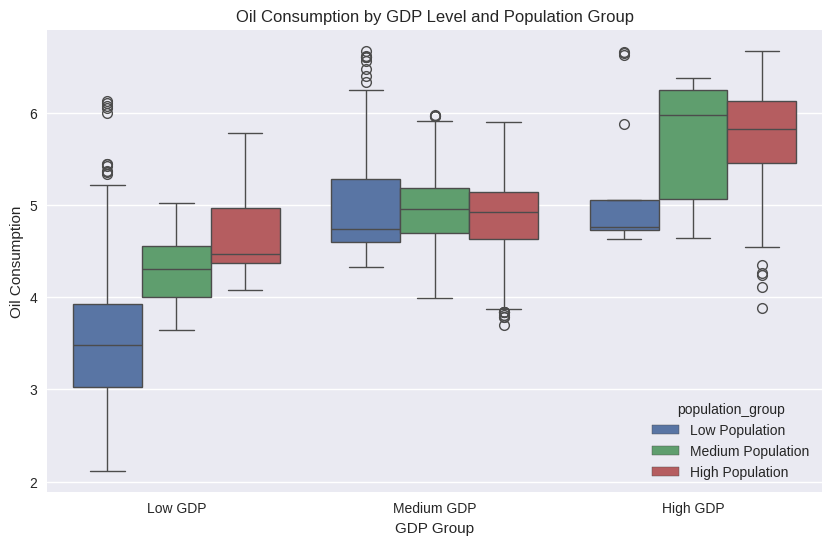

In [19]:
# 4. Visualization (Boxplot)

plt.figure(figsize=(10,6))

sns.boxplot(
    x='gdp_group',
    y='oil_consumption',
    hue='population_group',
    data=df
)

plt.title('Oil Consumption by GDP Level and Population Group')
plt.xlabel('GDP Group')
plt.ylabel('Oil Consumption')

plt.show()


In [20]:
# 5. ONE-WAY ANOVA (GDP Effect)

model_1way = ols('oil_consumption ~ C(gdp_group)', data=df).fit()
anova_1way = sm.stats.anova_lm(model_1way, typ=2)

print("\n=== ONE-WAY ANOVA (GDP) ===")
print(anova_1way)

# Interpretation:
# If p-value < 0.05 → GDP group significantly affects oil consumption
# If p-value > 0.05 → No significant effect


=== ONE-WAY ANOVA (GDP) ===
                  sum_sq      df            F         PR(>F)
C(gdp_group)  928.873747     2.0  1195.549404  1.531932e-307
Residual      563.672150  1451.0          NaN            NaN


In [21]:
# 6. Tukey Test (Post-hoc)

tukey = pairwise_tukeyhsd(
    df['oil_consumption'],
    df['gdp_group'],
    alpha=0.05
)

print("\n=== TUKEY TEST RESULT ===")
print(tukey)

# Interpretation:
# Shows which GDP groups differ (Low vs Medium, etc.)


=== TUKEY TEST RESULT ===
   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
 group1    group2   meandiff p-adj  lower   upper  reject
---------------------------------------------------------
High GDP    Low GDP  -1.9483   0.0 -2.0422 -1.8544   True
High GDP Medium GDP  -0.8128   0.0 -0.9068 -0.7189   True
 Low GDP Medium GDP   1.1354   0.0  1.0415  1.2294   True
---------------------------------------------------------


In [22]:
#Zhi hong add one code
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Perform Tukey's HSD test
tukey = pairwise_tukeyhsd(
    df['oil_consumption'],
    df['gdp_group'],
    alpha=0.05
)

# Print the Tukey HSD test results with p-adj formatted to 4 significant figures
print("\n=== TUKEY TEST RESULT ===")

# Get the summary of the Tukey test results
tukey_summary = tukey.summary()

# Format the p-adj column to 4 significant figures (sf)
formatted_results = []

# Loop through the summary and format the p-adj to 4 significant figures
for row in tukey_summary.data[1:]:  # Skip the header row
    formatted_row = list(row)  # Convert each row to a list for modification
    formatted_row[4] = f"{float(formatted_row[4]):.4g}"  # Format p-adj to 4 significant figures
    formatted_results.append(formatted_row)

# Print the formatted results
print(f"{'group1':<12} {'group2':<12} {'meandiff':<10} {'p-adj':<10} {'lower':<10} {'upper':<10} {'reject'}")
for row in formatted_results:
    print(f"{row[0]:<12} {row[1]:<12} {row[2]:<10} {row[4]:<10} {row[3]:<10} {row[5]:<10} {row[6]}")  # Print each row


=== TUKEY TEST RESULT ===
group1       group2       meandiff   p-adj      lower      upper      reject
High GDP     Low GDP      -1.9483    -2.042     0.0        -1.8544    True
High GDP     Medium GDP   -0.8128    -0.9068    0.0        -0.7189    True
Low GDP      Medium GDP   1.1354     1.042      0.0        1.2294     True


In [23]:
# 7. TWO-WAY ANOVA (GDP + Population)

model_2way = ols(
    'oil_consumption ~ C(gdp_group) * C(population_group)',
    data=df
).fit()

anova_2way = sm.stats.anova_lm(model_2way, typ=2)

print("\n=== TWO-WAY ANOVA ===")
print(anova_2way)

# Interpretation:
# C(gdp_group) → GDP effect
# C(population_group) → Population effect
# Interaction → Combined effect


=== TWO-WAY ANOVA ===
                                      sum_sq      df           F  \
C(gdp_group)                      385.140386     2.0  576.318214   
C(population_group)                37.206229     2.0   55.674835   
C(gdp_group):C(population_group)   43.635565     4.0   32.647798   
Residual                          482.830357  1445.0         NaN   

                                         PR(>F)  
C(gdp_group)                      9.368069e-185  
C(population_group)                5.094287e-24  
C(gdp_group):C(population_group)   4.325732e-26  
Residual                                    NaN  


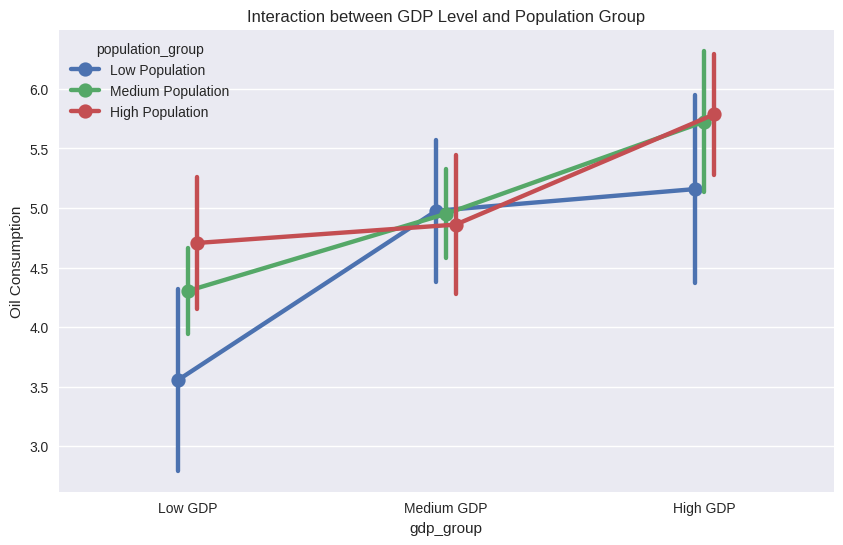

In [24]:
# 8. Interaction Plot

plt.figure(figsize=(10,6))

sns.pointplot(
    x='gdp_group',
    y='oil_consumption',
    hue='population_group',
    data=df,
    errorbar='sd',
    dodge=True
)

plt.title('Interaction between GDP Level and Population Group')
plt.ylabel('Oil Consumption')

plt.show()

# If lines are NOT parallel → interaction exists


In [25]:
# 9. ASSUMPTION TESTS

# 9.1 Normality Test (Shapiro-Wilk)
residuals = model_2way.resid

shapiro_test = stats.shapiro(residuals)

print("\n=== SHAPIRO-WILK TEST ===")
print(shapiro_test)

# Interpretation:
# p > 0.05 → Normal distribution (GOOD)
# p < 0.05 → Not normal



=== SHAPIRO-WILK TEST ===
ShapiroResult(statistic=np.float64(0.9860356503331816), pvalue=np.float64(1.260165673949073e-10))


In [26]:
# 9.2 Homogeneity of Variance (Levene Test)

levene_test = stats.levene(
    df[df['population_group'] == 'Low Population']['oil_consumption'],
    df[df['population_group'] == 'Medium Population']['oil_consumption'],
    df[df['population_group'] == 'High Population']['oil_consumption']
)

print("\n=== LEVENE TEST ===")
print(levene_test)

# Interpretation:
# p > 0.05 → Equal variance (GOOD)
# p < 0.05 → Not equal variance



=== LEVENE TEST ===
LeveneResult(statistic=np.float64(49.32094899033529), pvalue=np.float64(1.891748137345446e-21))


In [27]:
# FINAL INTERPRETATION & LIMITATIONS
print("=== FINAL CONCLUSION ===")
print("The Two-Way ANOVA shows that There is strong statistical evidence that GDP level affects oil consumption” (p < 0.001).")
print("There is also a significant interaction between GDP group and population group (p = 0.0002).")
print("High-GDP countries consume substantially more oil than low-GDP countries.")
print("\nHowever, the ANOVA results less reliable:")
print("- Residuals are not normally distributed (Shapiro-Wilk p << 0.05)")
print("- Variances are not equal across groups (Levene’s p << 0.05)")
print("Therefore, results should be interpreted with caution. A non-parametric test (e.g. Kruskal-Wallis) could be used as a robustness check.")

=== FINAL CONCLUSION ===
The Two-Way ANOVA shows that There is strong statistical evidence that GDP level affects oil consumption” (p < 0.001).
There is also a significant interaction between GDP group and population group (p = 0.0002).
High-GDP countries consume substantially more oil than low-GDP countries.

However, the ANOVA results less reliable:
- Residuals are not normally distributed (Shapiro-Wilk p << 0.05)
- Variances are not equal across groups (Levene’s p << 0.05)
Therefore, results should be interpreted with caution. A non-parametric test (e.g. Kruskal-Wallis) could be used as a robustness check.


In [28]:
# Non-parametric alternative (Kruskal-Wallis)
from scipy.stats import kruskal
kruskal_result = kruskal(
    df[df['gdp_group'] == 'Low GDP']['oil_consumption'],
    df[df['gdp_group'] == 'Medium GDP']['oil_consumption'],
    df[df['gdp_group'] == 'High GDP']['oil_consumption']
)
print("\nKruskal-Wallis Test (non-parametric):", kruskal_result)


Kruskal-Wallis Test (non-parametric): KruskalResult(statistic=np.float64(941.1029202235353), pvalue=np.float64(4.386290810282714e-205))
